SAMAGRA GUPTA 590014891 AIML B12

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("IRIS.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X.shape

(150, 4)

In [4]:
mean = np.mean(X, axis=0)
X_centered = X - mean

In [5]:
cov_matrix = np.cov(X_centered.T)
cov_matrix

array([[ 0.68569351, -0.03926846,  1.27368233,  0.5169038 ],
       [-0.03926846,  0.18800403, -0.32171275, -0.11798121],
       [ 1.27368233, -0.32171275,  3.11317942,  1.29638747],
       [ 0.5169038 , -0.11798121,  1.29638747,  0.58241432]])

In [6]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [7]:
sorted_index = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_index]
eigenvectors = eigenvectors[:, sorted_index]

In [8]:
pc2 = eigenvectors[:, :2]

In [9]:
pc3 = eigenvectors[:, :3]

In [10]:
X_pca2 = X_centered.dot(pc2)
X_pca3 = X_centered.dot(pc3)

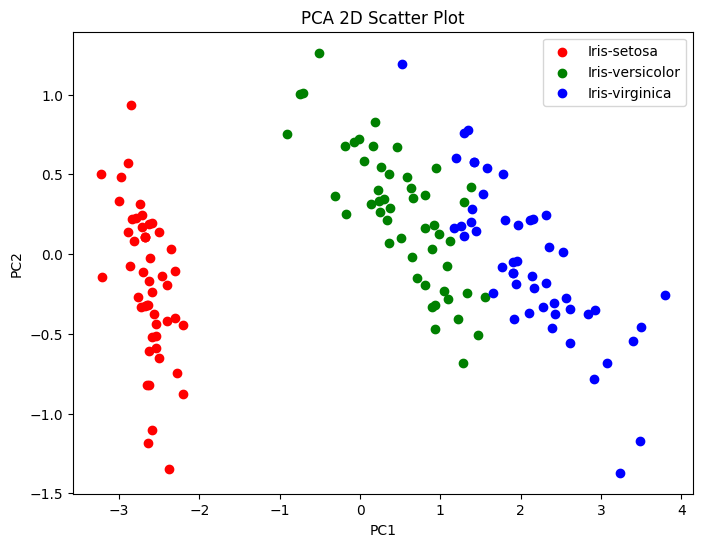

In [11]:
labels = np.unique(y)
colors = ['red', 'green', 'blue']

plt.figure(figsize=(8,6))

for label, color in zip(labels, colors):
    plt.scatter(X_pca2[y==label,0], X_pca2[y==label,1],
                label=label, color=color)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D Scatter Plot")
plt.legend()
plt.show()

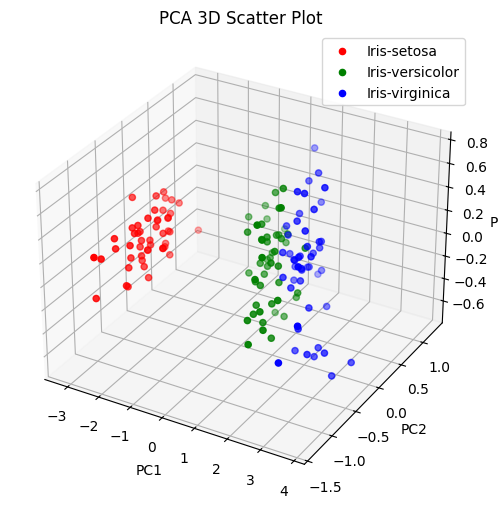

In [12]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

for label, color in zip(labels, colors):
    ax.scatter(X_pca3[y==label,0],
               X_pca3[y==label,1],
               X_pca3[y==label,2],
               label=label, color=color)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA 3D Scatter Plot")
ax.legend()

plt.show()